# TomatoMAP — Minimal BBCH Classification Training Demonstration

**Paper**: Y. Zhang, S. Struckmeyer, A. Kolb, S. Reichardt, *Tomato Multi-Angle Multi-Pose Dataset for Fine-Grained Phenotyping*, arXiv:2507.11279v1 (journal version: *Sci Data* 13:309, 2026).
**Code**: [0YJ/TomatoMAP](https://github.com/0YJ/TomatoMAP) @ commit `fc8f0a2ae1886fd399383c59d7fa6155d39b578b` (Apache-2.0).
**Data**: [Voxel51/tomato-map](https://huggingface.co/datasets/Voxel51/tomato-map) (CC BY 4.0, FiftyOne mirror built from the raw rig images + YOLO labels + ISAT JSONs; cites the e!DAL DOI [10.5447/ipk/2025/14](https://doi.org/10.5447/ipk/2025/14)).

## Scope and execution status — read first / 最初にお読みください

- **PARTIAL DEMONSTRATION, NOT a full-paper reproduction / 部分実演であり論文の完全再現ではありません。**
- What it does / 実行内容: trains the **authors' own** `mobilenet_v3_large` 50-class BBCH classifier with the **authors' own** hyperparameters (AdamW lr=1e-4, weight decay 0.01, StepLR(30, 0.1), CrossEntropy, 640×640 input, from `src/cls_trainer.py`) on a **small deterministic balanced subset** (12 images/class, 50 BBCH classes) of the TomatoMAP rig images, for a few epochs, and reports test accuracy + normalized confusion matrix.
- What it does NOT do / 実行しないこと: the paper's full 100-epoch training on the complete TomatoMAP-Cls split (paper reference: **79.19%** validation accuracy, Section 4). The subset result is a pipeline demonstration and is **not expected to match** 79.19%. YOLOv11 detection, Mask R-CNN segmentation, and the AI-vs-Human analysis are out of scope (the 295 AI-vs-Human external images were never released).
- No paper-trained checkpoint exists; the paper validates the dataset *by training*, so a narrowly scoped training run is the faithful minimal unit. The backbone uses torchvision's ImageNet `MobileNet_V3_Large_Weights` exactly as the authors' `get_model(pretrained=True)` does.
- Data note / データ注: the author deposit (e!DAL, 45.5 GB) only exposes one monolithic ZIP, so this notebook uses the verified public FiftyOne mirror; every downloaded byte is hash/size-checked here. The authors' exact train/val/test split is not distributed (it depends on the full raw file ordering), so this notebook builds its own deterministic split with the authors' ratios (70/20/10) and per-class shuffle-seed convention (`random.seed(888)` from `TomatoMAP_builder.ipynb`).

日本語: このノートブックは著者自身のモデル定義・ハイパーパラメータを用い、TomatoMAP のリグ画像から各BBCHクラス12枚・計600枚の決定論的サブセットで少数エポック学習する**部分実演**です。論文の79.19%(全データ・100エポック)には一致しません。著者リポジトリのコードをピン留めコミットから取得して使用します。

## 1. Runtime selection / ランタイム選択

- **Recommended: T4 GPU** (Runtime → Change runtime type → T4 GPU). Total expected wall time ≈ 5–10 min.
- **CPU also works** with the identical steps; expect ≈ 15–30 min (MobileNetV3-Large forward+backward at 640×640 on CPU is the bottleneck). The notebook detects the device automatically — no code changes needed.
- Downloads ≈ 0.6 GB total: `samples.json` (218 MB) + ~600 rig images (~0.5 MB each) + ImageNet backbone weights (~22 MB).
- 推奨はT4 GPUです。CPUでも同一手順で動作しますが学習が遅くなります。ダウンロード合計は約0.6GBです。

### 1.1 Environment check

Prints Python/torch/torchvision versions and the allocated device. On CPU runtimes `cuda` will be `False` — that is expected and fine. 日本語: 環境とデバイスを確認します。CPUランタイムでは cuda=False が正常です。

In [ ]:
import platform, torch, torchvision
print('python  ', platform.python_version())
print('torch   ', torch.__version__)
print('torchvis', torchvision.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print('gpu     ', torch.cuda.get_device_name(0),
          f'{torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
print('device  ', device)

python   3.13.15
torch    2.11.0+cu130
torchvis 0.26.0+cu130
gpu      Tesla T4 14.6 GB
device   cuda


## 2. Fetch the pinned author code / 著者コードの取得

Fetches `0YJ/TomatoMAP` at the exact verified commit with a blob-less partial clone, then checks out only `src/` (the classification path). The checked-out commit is asserted against the pin. All repository objects stay under `/content`. 日本語: 著者リポジトリをピン留めコミットで部分クローンし、分類用の `src/` のみチェックアウトします。

In [ ]:
import os, subprocess

COMMIT = 'fc8f0a2ae1886fd399383c59d7fa6155d39b578b'
REPO_DIR = '/content/TomatoMAP_code'

env = dict(os.environ)
env['GIT_LFS_SKIP_SMUDGE'] = '1'  # never smudge LFS objects automatically

def git(*args, **kw):
    r = subprocess.run(['git', *args], env=env, capture_output=True, text=True, timeout=300, **kw)
    assert r.returncode == 0, f'git {args[:2]} failed: {r.stderr[-400:]}'
    return r.stdout.strip()

if not os.path.isdir(REPO_DIR):
    git('clone', '--filter=blob:none', '--no-checkout',
        'https://github.com/0YJ/TomatoMAP.git', REPO_DIR)
os.chdir(REPO_DIR)
git('fetch', '--depth', '1', 'origin', COMMIT)
git('checkout', '--force', 'FETCH_HEAD')
assert git('rev-parse', 'HEAD') == COMMIT
git('sparse-checkout', 'set', 'src')
git('checkout', 'HEAD', '--', 'src')  # materialize only src/
print('pinned author code at', git('rev-parse', 'HEAD'))
print(sorted(os.listdir(os.path.join(REPO_DIR, 'src'))))

pinned author code at fc8f0a2ae1886fd399383c59d7fa6155d39b578b
['avh', 'cls', 'cls_trainer.py', 'datasets', 'det_balanced_trainer.py', 'det_trainer.py', 'models', 'seg_trainer.py', 'utils']


### 2.1 Import the author's dataset/model/visualization modules

Colab ships the HuggingFace `datasets` package, which would shadow the author's `src/datasets/` directory (a regular package beats a namespace package regardless of `sys.path` order), so the author modules are loaded **from their pinned file paths** with `importlib` — identical code, collision-free import. 日本語: Colab同梱の `datasets` パッケージとの名前衝突を避けるため、著者モジュールをピン留めファイルから直接ロードします（コードは同一）。

In [ ]:
import importlib.util, sys

SRC = '/content/TomatoMAP_code/src'

def load_author(name, path):
    spec = importlib.util.spec_from_file_location(f'tomatomap_{name}', path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[f'tomatomap_{name}'] = mod
    spec.loader.exec_module(mod)
    return mod

cls_dataset   = load_author('cls_dataset',   f'{SRC}/datasets/cls_dataset.py')
cls_models    = load_author('cls_models',    f'{SRC}/models/cls_models.py')
common        = load_author('common',        f'{SRC}/utils/common.py')
visualization = load_author('visualization', f'{SRC}/utils/visualization.py')

BBCHDataset     = cls_dataset.BBCHDataset
get_transforms  = cls_dataset.get_transforms
get_model       = cls_models.get_model
get_num_workers = common.get_num_workers
print('author modules loaded:',
      'BBCHDataset', 'get_transforms', 'get_model', 'get_num_workers')

author modules loaded: BBCHDataset get_transforms get_model get_num_workers


## 3. Acquire the BBCH-labeled sample index / サンプル索引の取得

Downloads `samples.json` from the **pinned HF revision** `c978c56cfc6d1bd35d0b34709f9b14cfc85b165f` and verifies its SHA-256 (metadata from the HF tree API; the mirror card states it was built from the raw rig images + YOLO labels + ISAT JSONs and cites both paper DOIs). Each of the 64,464 rig ('det') samples carries `bbch_stage` + `bbch_description` + camera/plant/pose metadata. 日本語: ピン留めしたリビジョンから samples.json を取得しSHA-256で検証します。

In [ ]:
import hashlib, urllib.request, pathlib

HF_REV = 'c978c56cfc6d1bd35d0b34709f9b14cfc85b165f'
SAMPLES_URL = f'https://huggingface.co/datasets/Voxel51/tomato-map/resolve/{HF_REV}/samples.json'
SAMPLES_SHA256 = '70527e3887877f289c0016aa6327b5da0f00111e6916239e46817633e6ef93b6'

dst = pathlib.Path('/content/samples.json')
if not dst.exists() or hashlib.sha256(dst.read_bytes()).hexdigest() != SAMPLES_SHA256:
    print('downloading', SAMPLES_URL)
    with urllib.request.urlopen(SAMPLES_URL, timeout=180) as r, open(dst, 'wb') as f:
        while True:
            chunk = r.read(1 << 22)
            if not chunk:
                break
            f.write(chunk)
h = hashlib.sha256(dst.read_bytes()).hexdigest()
assert h == SAMPLES_SHA256, h
print('samples.json verified:', dst.stat().st_size, 'bytes, sha256 OK')

downloading https://huggingface.co/datasets/Voxel51/tomato-map/resolve/c978c56cfc6d1bd35d0b34709f9b14cfc85b165f/samples.json


samples.json verified: 218203497 bytes, sha256 OK


### 3.1 Select a deterministic balanced subset and build the ImageFolder layout

Mirrors the authors' builder recipe (`TomatoMAP_builder.ipynb` @ fc8f0a2): per-class seeded shuffle with `random.seed(888)`, class dirs named `bbch_{value:02d}`, and their exact 70/20/10 split arithmetic (`n_train = max(1, int(n*0.7))`, val only if `n > 2`). With **12 images per class** this yields 400 train / 100 val / 100 test images across all **50 BBCH classes**. Selection is sorted-by-filepath first, so the result is fully deterministic. A per-image provenance manifest is written under `TomatoMAP-Cls/manifest/`. 日本語: 著者のビルダー手順（seed 888、bbch_XX ディレクトリ、70/20/10）に倣い、クラスごと12枚の決定論的サブセットを作成します。

In [ ]:
import json, random, shutil
from collections import defaultdict
from pathlib import Path

PER_CLASS = 12
SPLIT_RATIOS = (0.7, 0.2, 0.1)  # author's builder ratios
SEED = 888                       # author's builder seed

with open('/content/samples.json') as f:
    samples = json.load(f)['samples']

det = [s for s in samples if 'det' in (s.get('tags') or [])]
print('rig (det) samples:', len(det))
stages = sorted({s['bbch_stage'] for s in det})
print('BBCH classes:', len(stages), '->', stages[0], '..', stages[-1])

by_class = defaultdict(list)
for s in sorted(det, key=lambda s: s['filepath']):
    by_class[s['bbch_stage']].append(s)

rng = random.Random(SEED)  # same seed value the authors' builder uses
selected = {'train': [], 'val': [], 'test': []}
for stage in stages:
    imgs = by_class[stage]
    picked = imgs[:PER_CLASS]
    picked = picked.copy(); rng.shuffle(picked)
    n_total = len(picked)
    n_train = max(1, int(n_total * SPLIT_RATIOS[0]))
    n_val   = max(1, int(n_total * SPLIT_RATIOS[1])) if n_total > 2 else 0
    selected['train'] += [(stage, s) for s in picked[:n_train]]
    selected['val']   += [(stage, s) for s in picked[n_train:n_train+n_val]]
    selected['test']  += [(stage, s) for s in picked[n_train+n_val:]]

DATA_ROOT = Path('/content/TomatoMAP-Cls')
if DATA_ROOT.exists():
    shutil.rmtree(DATA_ROOT)
(DATA_ROOT / 'manifest').mkdir(parents=True)
for split, items in selected.items():
    for stage, s in items:
        (DATA_ROOT / split / f'bbch_{stage:02d}').mkdir(parents=True, exist_ok=True)
        stem = Path(s['filepath']).stem
        (DATA_ROOT / 'manifest' / f'{stem}.json').write_text(json.dumps(s))

for split, items in selected.items():
    print(split, len(items), 'images')
print('total', sum(len(v) for v in selected.values()), 'images across', len(stages), 'classes')

rig (det) samples: 64464
BBCH classes: 50 -> 13 .. 89


train 400 images
val 100 images
test 100 images
total 600 images across 50 classes


### 3.2 Download the selected rig images

Fetches only the selected images from the pinned revision with 8 parallel workers (≈330 MB), verifies each is a loadable JPEG of the acquisition resolution (1080×1440, Section 2.1 of the paper), and writes it into its split/class directory. Failures raise rather than being skipped. 日本語: 選択した画像のみをピン留めリビジョンから並列取得し、JPEGとして検証してから配置します。

In [ ]:
import io, urllib.request
from concurrent.futures import ThreadPoolExecutor
from PIL import Image

BASE = f'https://huggingface.co/datasets/Voxel51/tomato-map/resolve/{HF_REV}/'

place = {}
for split, items in selected.items():
    for stage, s in items:
        place[Path(s['filepath']).name] = (split, stage, s['filepath'])

def fetch(name):
    split, stage, rel = place[name]
    raw = urllib.request.urlopen(BASE + rel, timeout=120).read()
    im = Image.open(io.BytesIO(raw))
    if im.size != (1080, 1440):
        raise ValueError(f'{name}: unexpected size {im.size}')
    (DATA_ROOT / split / f'bbch_{stage:02d}' / name).write_bytes(raw)
    return name

names = list(place)
with ThreadPoolExecutor(max_workers=8) as ex:
    for i, _ in enumerate(ex.map(fetch, names), 1):
        if i % 100 == 0:
            print(f'{i}/{len(names)} downloaded', flush=True)

n = sum(1 for _ in DATA_ROOT.rglob('*.jpg'))
assert n == len(names), (n, len(names))
print('placed', n, 'verified JPEGs at', DATA_ROOT)

100/600 downloaded


200/600 downloaded


300/600 downloaded


400/600 downloaded


500/600 downloaded


600/600 downloaded


placed 600 verified JPEGs at /content/TomatoMAP-Cls


### 3.3 Input preview — one real rig image per BBCH stage with its real label

Displays actual downloaded images with their BBCH stage + description (the annotation this reproduction trains on; stage→description mapping from the mirror's `bbch_description` field, consistent with the paper's BBCH scale, Supplemental Table S1). This is the annotation view of real inputs, not a model prediction. 日本語: 実画像とそのBBCHラベル（正解注釈）を表示します。

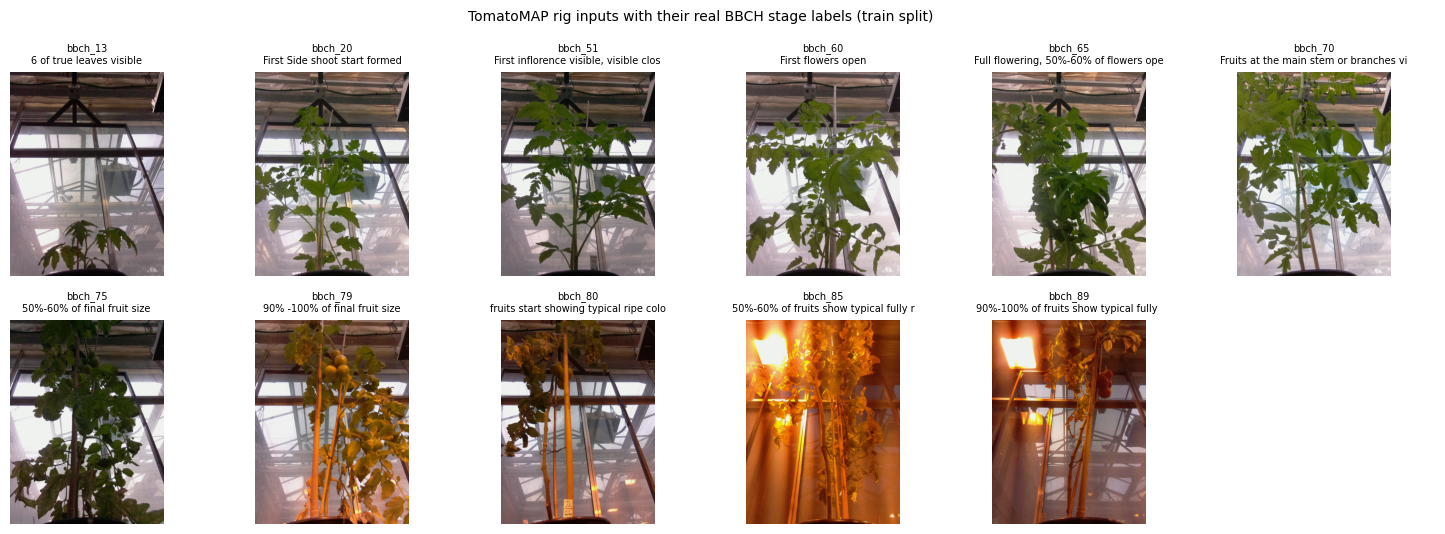

In [ ]:
import matplotlib.pyplot as plt

stage_desc = {}
for s in det:
    stage_desc.setdefault(s['bbch_stage'], s['bbch_description'])

show_stages = [13, 20, 51, 60, 65, 70, 75, 79, 80, 85, 89]
fig, axes = plt.subplots(2, 6, figsize=(15, 5.4))
for ax, stage in zip(axes.ravel(), show_stages):
    img_path = next((DATA_ROOT / 'train' / f'bbch_{stage:02d}').glob('*.jpg'))
    ax.imshow(Image.open(img_path))
    ax.set_title(f'bbch_{stage:02d}\n{stage_desc[stage][:38]}', fontsize=7)
    ax.axis('off')
for ax in axes.ravel()[len(show_stages):]:
    ax.axis('off')
fig.suptitle('TomatoMAP rig inputs with their real BBCH stage labels (train split)', fontsize=10)
fig.tight_layout()
fig.savefig('/content/input_preview.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.4 Multi-angle view of one plant capture

The dataset's defining feature is 4 camera elevations × 12 turntable poses per session. In the mirror, `piid` is the camera index (1–4 = 45°/90°/135°/180° fisheye), `plant_id` the plant, `pose_id` the turntable pose (0°–330°), and the four cameras share `(plant_id, pose_id, image number)` with slightly offset capture timestamps. One such camera group is selected deterministically and displayed. 日本語: piidはカメラ番号（1–4=各仰角）で、4カメラは同一(植物,ポーズ,画像番号)を共有します。そのグループを表示します。

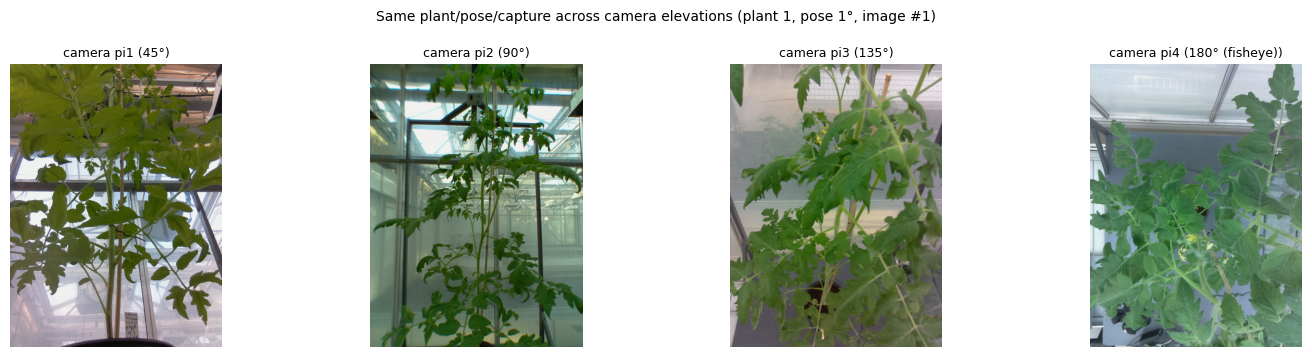

In [ ]:
from collections import defaultdict

cam_groups = defaultdict(dict)  # (plant_id, pose_id, img#) -> {angle: filepath}
for s in det:
    parts = Path(s['filepath']).stem.split('_')
    cam_groups[(s['plant_id'], s['pose_id'], int(parts[1]))][s['piid']] = s['filepath']

complete = [k for k, v in sorted(cam_groups.items()) if set(v) == {1, 2, 3, 4}]
assert complete, 'no complete 4-camera group found'
key = complete[0]
angle_names = {1: '45°', 2: '90°', 3: '135°', 4: '180° (fisheye)'}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, angle in zip(axes, [1, 2, 3, 4]):
    ax.imshow(Image.open(io.BytesIO(urllib.request.urlopen(BASE + cam_groups[key][angle], timeout=120).read())))
    ax.set_title(f'camera pi{angle} ({angle_names[angle]})', fontsize=9)
    ax.axis('off')
fig.suptitle(f'Same plant/pose/capture across camera elevations (plant {key[0]}, pose {key[1]}°, image #{key[2]})', fontsize=10)
fig.tight_layout()
fig.savefig('/content/angles_preview.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Build the author's dataset and loaders / データパイプライン

Uses the authors' own `BBCHDataset` and `get_transforms(640×640)`: train = resize + horizontal flip + ±10° rotation + color jitter + ImageNet normalization; val/test = resize + normalization. Batch size 32 is the authors' CLI default (`main.py`). 日本語: 著者自身のBBCHDataset/get_transforms（640×640、ImageNet正規化）とデフォルトバッチ32を使用します。

In [ ]:
from torch.utils.data import DataLoader

train_tf, val_tf = get_transforms((640, 640))
train_ds = BBCHDataset(str(DATA_ROOT), 'train', train_tf)
val_ds   = BBCHDataset(str(DATA_ROOT), 'val',   val_tf)
test_ds  = BBCHDataset(str(DATA_ROOT), 'test',  val_tf)

BATCH_SIZE = 32  # authors' default (main.py --batch-size 32)
num_workers = get_num_workers()
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=num_workers, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=(device.type=='cuda'))

print('classes:', len(train_ds.classes), train_ds.classes[:5], '...')
print('train/val/test:', len(train_ds), len(val_ds), len(test_ds))
x, y = next(iter(train_loader))
print('batch tensor:', tuple(x.shape), x.dtype, '| first labels:', y[:8].tolist())

Loaded train dataset: 400 images, 50 classes
Loaded val dataset: 100 images, 50 classes
Loaded test dataset: 100 images, 50 classes
classes: 50 ['bbch_13', 'bbch_14', 'bbch_15', 'bbch_16', 'bbch_17'] ...
train/val/test: 400 100 100


batch tensor: (32, 3, 640, 640) torch.float32 | first labels: [14, 17, 40, 3, 43, 8, 49, 18]


## 5. Model — the authors' `get_model('mobilenet_v3_large', 50)`

Exactly the author definition: torchvision `mobilenet_v3_large` with ImageNet `DEFAULT` weights, final classifier layer replaced by `nn.Linear(960, 50)`. The optimizer/scheduler/loss follow `cls_trainer.py` exactly. 日本語: 著者定義どおり、ImageNet事前学習のMobileNetV3-Largeの最終層を50クラスに置換し、著者の最適化設定を使用します。

In [ ]:
import torch.nn as nn, torch.optim as optim

model = get_model('mobilenet_v3_large', 50, pretrained=True).to(device)  # author's factory
criterion = nn.CrossEntropyLoss()                                       # author's loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)  # author's optimizer
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)  # author's schedule
print('model on', device)

Building model: mobilenet_v3_large, classes: 50


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


  0%|          | 0.00/21.1M [00:00<?, ?B/s]

 61%|██████    | 12.9M/21.1M [00:00<00:00, 135MB/s]

100%|██████████| 21.1M/21.1M [00:00<00:00, 138MB/s]

Parameters - Total: 4,266,082, Trainable: 4,266,082
model on cuda


## 6. Train — faithful port of the authors' `cls_trainer.py` loop

Same order of operations as `ClassificationTrainer.train_epoch/validate_epoch` (forward → CE loss → AdamW step → running accuracy; validation under `torch.no_grad()`; StepLR each epoch). Only the epoch count is reduced to **3** for this subset demo (authors: up to 100 with early stopping). Progress bars use `tqdm` like the original. 日本語: 著者の学習ループを忠実に移植（エポック数のみ3に短縮）。

In [ ]:
import time
from tqdm.auto import tqdm

EPOCHS = 3  # subset demonstration; authors train up to 100 epochs on the full Cls split
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_acc, start = 0.0, time.time()

for epoch in range(EPOCHS):
    model.train()
    tl, tc, tt = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f'epoch {epoch+1}/{EPOCHS} [train]', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        tl += loss.item()
        _, pred = torch.max(outputs.data, 1)
        tt += labels.size(0); tc += (pred == labels).sum().item()
    train_loss, train_acc = tl / len(train_loader), 100 * tc / tt

    model.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'epoch {epoch+1}/{EPOCHS} [val]', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            vl += criterion(outputs, labels).item()
            _, pred = torch.max(outputs.data, 1)
            vt += labels.size(0); vc += (pred == labels).sum().item()
    val_loss, val_acc = vl / len(val_loader), 100 * vc / vt

    scheduler.step()
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc);   history['val_acc'].append(val_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    best_val_acc = max(best_val_acc, val_acc)
    print(f'epoch {epoch+1}: train acc {train_acc:.2f}% | val acc {val_acc:.2f}%')

print(f'training wall time: {time.time()-start:.0f}s | best val acc: {best_val_acc:.2f}%')

epoch 1/3 [train]:   0%|          | 0/13 [00:00<?, ?it/s]

epoch 1/3 [val]:   0%|          | 0/4 [00:00<?, ?it/s]

epoch 1: train acc 5.00% | val acc 10.00%


Exception ignored in: 

<function _MultiProcessingDataLoaderIter.__del__ at 0x78dac839ba60>

...

assert self._parent_pid == os.getpid(), 'can only test a child process'

AssertionError

: 

can only test a child process

epoch 3: train acc 29.75% | val acc 17.00%
training wall time: 221s | best val acc: 17.00%


### 6.1 Training curves (author's `plot_training_curves`)

Renders the authors' own curve function over this run's history and displays the saved PNG. 日本語: 著者の関数で学習曲線を描画します（このサブセット実行の結果）。

Training curves saved to: /content/outputs/training_curves.png


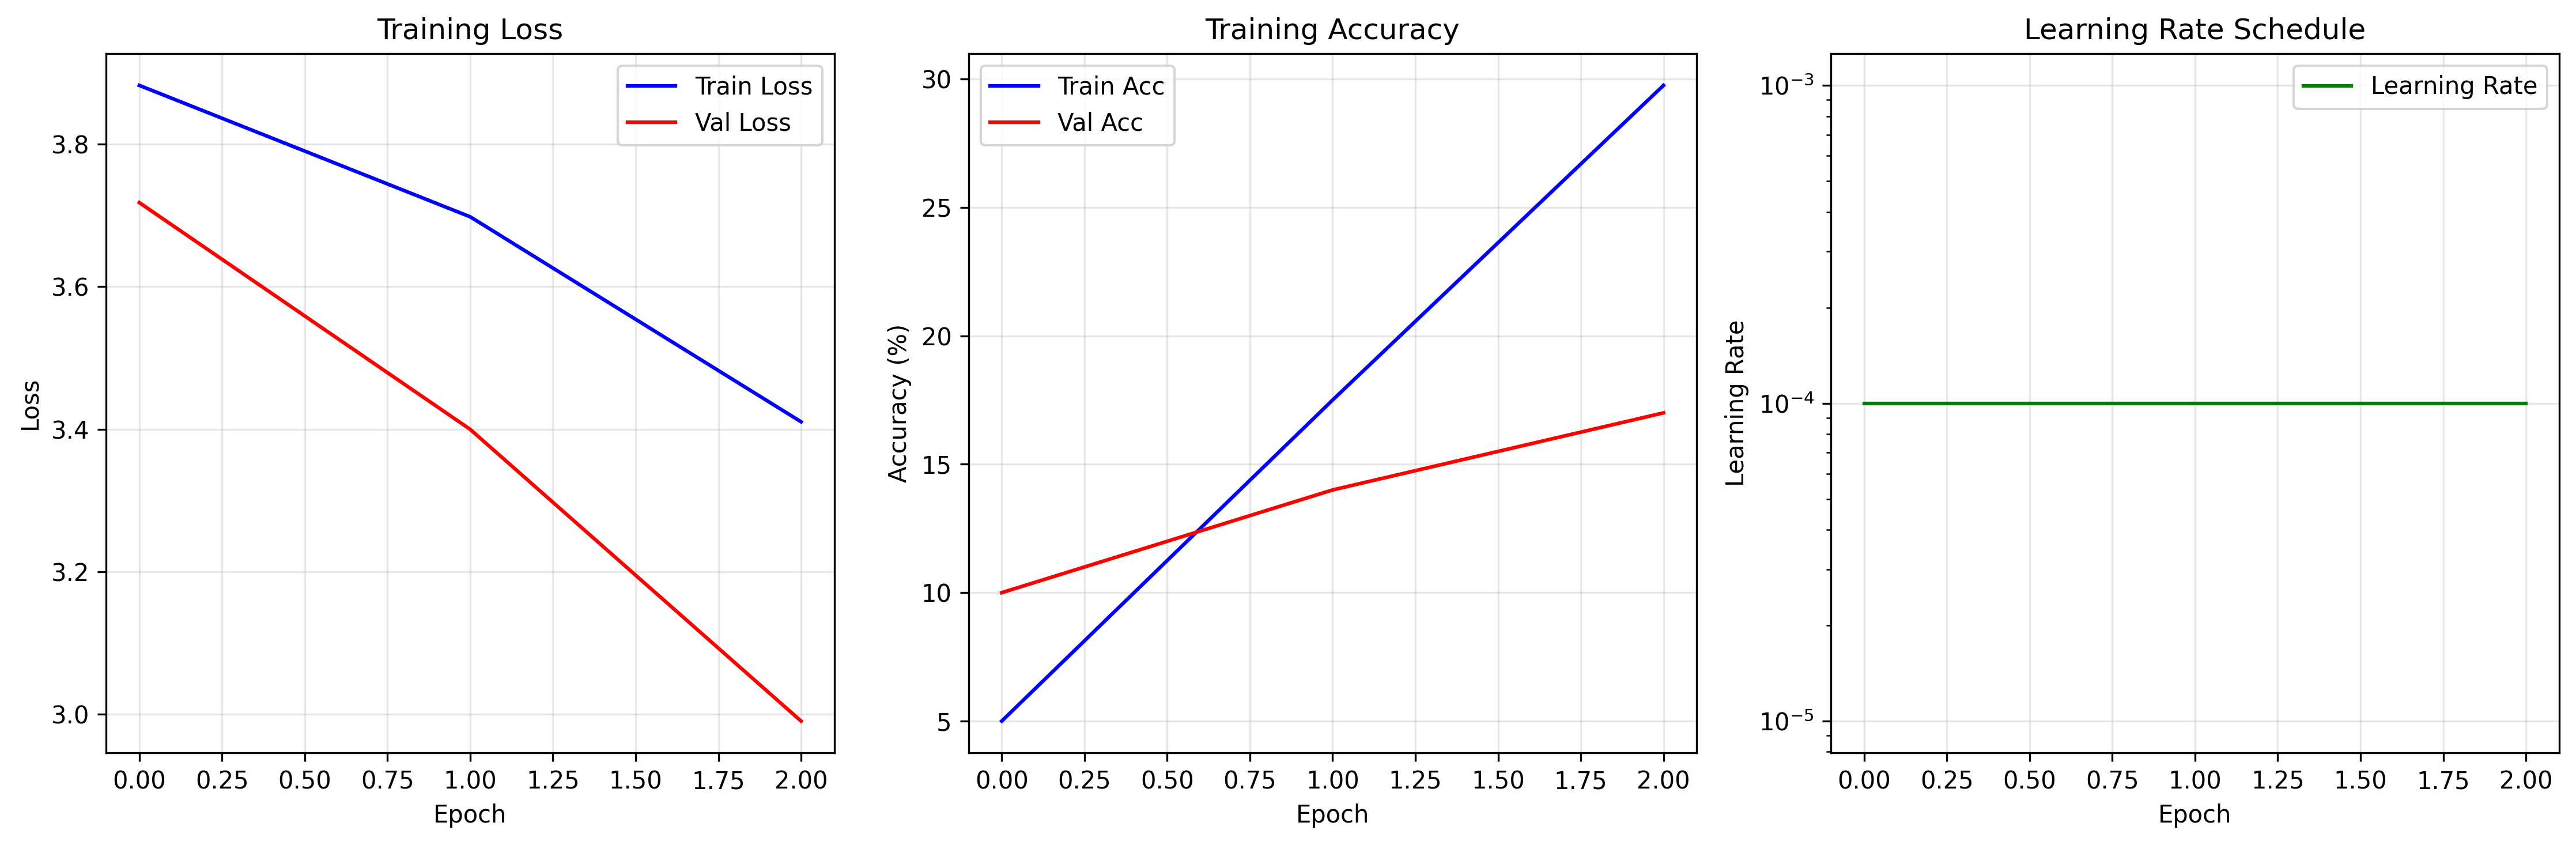

In [ ]:
os.makedirs('/content/outputs', exist_ok=True)
visualization.plot_training_curves(history, '/content/outputs')
from IPython.display import Image as IImage, display
display(IImage(filename='/content/outputs/training_curves.png'))

## 7. Evaluate on the held-out test split — author's `evaluate()` logic

Runs the test split with this run's trained weights (no external checkpoint exists — the paper released none), computes test accuracy, and renders the authors' normalized confusion matrix (their exact `create_confusion_matrix`, including the paper-style jet colormap with zero cells masked white, Section 4/Figure 6 style). 日本語: テスト分割で評価し、著者の正規化混同行列関数で可視化します。

testing:   0%|          | 0/4 [00:00<?, ?it/s]

test accuracy: 25.00% (25/100)


Confusion matrix saved to: /content/outputs/normalized_confusion_matrix.png


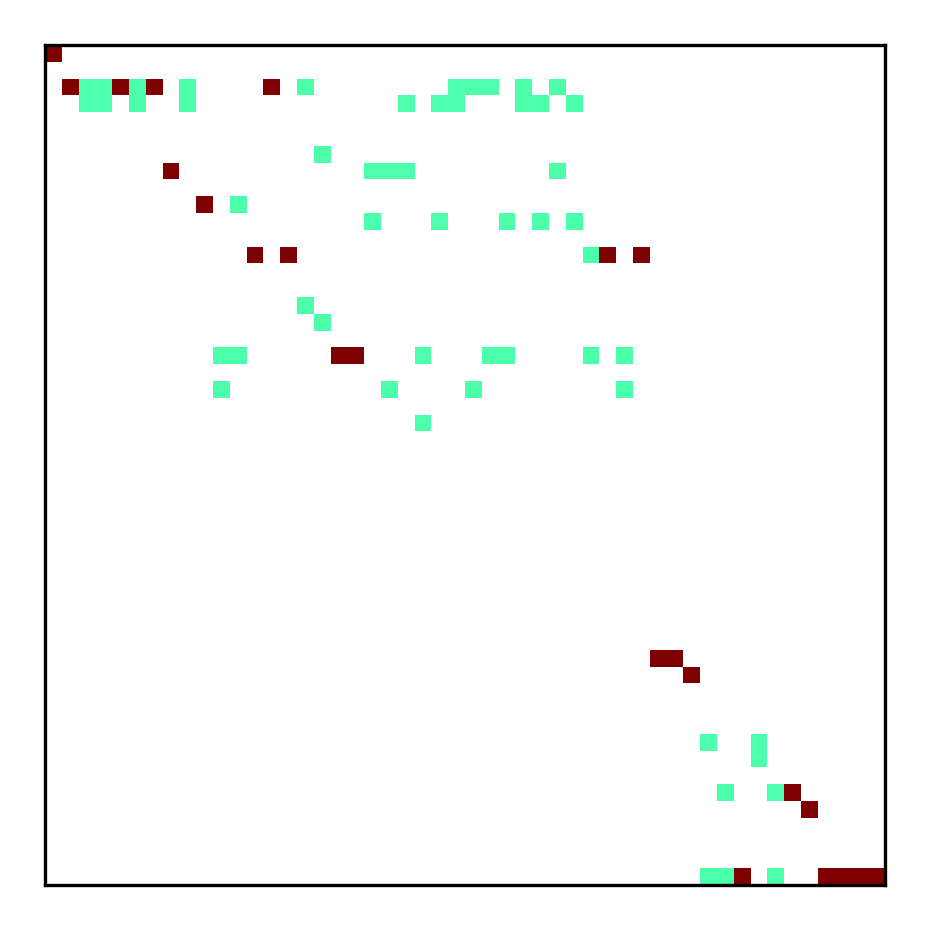

In [ ]:
model.eval()
test_correct, test_total = 0, 0
test_preds, test_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='testing', leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, pred = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (pred == labels).sum().item()
        test_preds.extend(pred.cpu().numpy()); test_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * test_correct / test_total
print(f'test accuracy: {test_accuracy:.2f}% ({test_correct}/{test_total})')
class_names = train_ds.classes  # 'bbch_13' ... 'bbch_89', author's ImageFolder convention
visualization.create_confusion_matrix(test_labels, test_preds, class_names, '/content/outputs')
display(IImage(filename='/content/outputs/normalized_confusion_matrix.png'))

### 7.1 Small results table and CSV export

Writes the authors' `test_results.json` / `confusion_matrix.csv` outputs and shows a compact per-class accuracy table. 日本語: 結果テーブルとCSVを出力します。

In [ ]:
import pandas as pd

per_class = {}
for i, cname in enumerate(class_names):
    idx = [j for j, t in enumerate(test_labels) if t == i]
    if idx:
        per_class[cname] = 100.0 * sum(test_preds[j] == i for j in idx) / len(idx)
pc = pd.Series(per_class, name='test_acc_%').sort_index().to_frame()
display(pc.T)
pc.to_csv('/content/outputs/per_class_accuracy.csv')

test_results = {'test_accuracy': test_accuracy, 'total_samples': test_total,
                'correct_predictions': test_correct, 'num_classes': len(class_names),
                'scope': 'subset demo: 12 imgs/class, 3 epochs',
                'paper_reference_val_acc_full_split': 79.19}
pd.Series(test_results).to_json('/content/outputs/test_results.json')
print('saved: outputs/test_results.json, outputs/confusion_matrix.csv, outputs/per_class_accuracy.csv')

,bbch_13,bbch_14,bbch_15,bbch_16,bbch_17,bbch_19,bbch_20,bbch_21,bbch_22,bbch_23,...,bbch_80,bbch_81,bbch_82,bbch_83,bbch_84,bbch_85,bbch_86,bbch_87,bbch_88,bbch_89
test_acc_%,100.0,0.0,50.0,50.0,0.0,0.0,0.0,100.0,0.0,100.0,...,0.0,0.0,50.0,0.0,100.0,100.0,0.0,0.0,0.0,100.0


saved: outputs/test_results.json, outputs/confusion_matrix.csv, outputs/per_class_accuracy.csv


## 8. Interpretation — subset demo vs. the paper / 結果の解釈

- **This run**: trained the authors' model/hyperparameters on 600 deterministically sampled rig images (12/BBCH class, 3 epochs). The test accuracy and confusion matrix above characterize **this subset demo only**.
- **The paper's 79.19%** (Section 4) comes from training on the **complete TomatoMAP-Cls split for up to 100 epochs** on a V100. Do not compare the two numerically; confusion concentrated between adjacent growth stages (e.g., the BBCH 7x fruit-sizing stages) is the pattern the paper also reports.
- Differences / 違い: own split (authors' exact split not distributed), subset scale, reduced epochs, third-party verified mirror as the byte source (author deposit exposes only a 45.5 GB monolithic ZIP), and importlib-based module loading to avoid the Colab `datasets` name collision. All author numerical operations (loss, optimizer, schedule, transforms, split ratios, class naming) are unchanged.
- Provenance: code `0YJ/TomatoMAP@fc8f0a2` (Apache-2.0); data `Voxel51/tomato-map@c978c56` (CC BY 4.0) built from the raw rig images + YOLO labels + ISAT JSONs; original deposit DOI 10.5447/ipk/2025/14; paper arXiv:2507.11279v1 / Sci Data 13:309 (2026).
- Validation record: this notebook was executed top-to-bottom on fresh Colab runtimes; see the run report for the exact hardware/date. 日本語: 本実行はサブセット実演です。論文の79.19%は完全データ・100エポックの結果であり、数値比較はできません。